In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Transformation

In [ ]:
food = pd.read_csv("/content/food.csv")
food_nutrient = pd.read_csv("/content/food_nutrient.csv")
nutrient = pd.read_csv("/content/nutrient.csv")

In [ ]:
print(food.shape)
print(food_nutrient.shape)
print(nutrient.shape)

(7793, 5)
(644125, 11)
(474, 5)


In [ ]:
food.head()

,fdc_id,data_type,description,food_category_id,publication_date
0,167512,sr_legacy_food,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...",18,2019-04-01
1,167513,sr_legacy_food,"Pillsbury, Cinnamon Rolls with Icing, refriger...",18,2019-04-01
2,167514,sr_legacy_food,"Kraft Foods, Shake N Bake Original Recipe, Coa...",18,2019-04-01
3,167515,sr_legacy_food,"George Weston Bakeries, Thomas English Muffins",18,2019-04-01
4,167516,sr_legacy_food,"Waffles, buttermilk, frozen, ready-to-heat",18,2019-04-01


In [ ]:
food_nutrient.head()

,id,fdc_id,nutrient_id,amount,data_points,derivation_id,min,max,median,footnote,min_year_acquired
0,1283674,167512,1003,5.88,1,46.0,NaN,NaN,NaN,NaN,NaN
1,1283675,167512,1007,3.50,1,46.0,NaN,NaN,NaN,NaN,NaN
2,1283676,167512,1062,1286.00,0,49.0,NaN,NaN,NaN,NaN,NaN
3,1283677,167512,1079,1.20,1,46.0,NaN,NaN,NaN,NaN,NaN
4,1283678,167512,1089,2.12,1,46.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
nutrient.head()

,id,name,unit_name,nutrient_nbr,rank
0,2047,Energy (Atwater General Factors),KCAL,957.0,280.0
1,2048,Energy (Atwater Specific Factors),KCAL,958.0,290.0
2,1001,Solids,G,201.0,200.0
3,1002,Nitrogen,G,202.0,500.0
4,1003,Protein,G,203.0,600.0


In [ ]:
food['data_type'].value_counts()

,count
data_type,
sr_legacy_food,7793


In [ ]:
nutrient[nutrient.name.str.contains('potassi', case=False)]

,id,name,unit_name,nutrient_nbr,rank
93,1092,"Potassium, K",MG,306.0,5700.0


In [ ]:
important_nutrients = [
    1008,  # Energy
    1003,  # Protein
    1004,  # Total Fat
    1258,  # Saturated Fat
    1257,  # Trans Fat
    1005,  # Carbohydrate
    2000,  # Sugars
    1079,  # Fiber
    1093,  # Sodium
    1253,  # Cholesterol
    1092,  # Potassium
]

nutrient_map = (
    nutrient[nutrient['id'].isin(important_nutrients)]
    .set_index('id')['name']
    .to_dict()
)

nutrient_map

{1003: 'Protein',
 1004: 'Total lipid (fat)',
 1005: 'Carbohydrate, by difference',
 1008: 'Energy',
 1079: 'Fiber, total dietary',
 1092: 'Potassium, K',
 1093: 'Sodium, Na',
 1253: 'Cholesterol',
 1257: 'Fatty acids, total trans',
 1258: 'Fatty acids, total saturated',
 2000: 'Sugars, Total'}

In [ ]:
food_nutrient = food_nutrient[
    food_nutrient['nutrient_id'].isin(important_nutrients)
]
food_nutrient.shape

(78658, 11)

In [ ]:
food_nutrient.head()

,id,fdc_id,nutrient_id,amount,data_points,derivation_id,min,max,median,footnote,min_year_acquired
0,1283674,167512,1003,5.880,1,46.0,NaN,NaN,NaN,NaN,NaN
3,1283677,167512,1079,1.200,1,46.0,NaN,NaN,NaN,NaN,NaN
5,1283679,167512,1093,1059.000,1,46.0,NaN,NaN,NaN,NaN,NaN
6,1283680,167512,1253,0.000,1,46.0,NaN,NaN,NaN,NaN,NaN
7,1283681,167512,1257,4.412,1,46.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
df = food_nutrient.pivot(
    index='fdc_id',
    columns='nutrient_id',
    values='amount'
).reset_index()
df = df.rename(columns=nutrient_map)
df.shape

(7793, 12)

In [ ]:
df.head()

nutrient_id,fdc_id,Protein,Total lipid (fat),"Carbohydrate, by difference",Energy,"Fiber, total dietary","Potassium, K","Sodium, Na",Cholesterol,"Fatty acids, total trans","Fatty acids, total saturated","Sugars, Total"
0,167512,5.88,13.24,41.18,307.0,1.2,NaN,1059.0,0.0,4.412,2.941,5.88
1,167513,4.34,11.27,53.42,330.0,1.4,NaN,780.0,0.0,4.290,3.250,21.34
2,167514,6.10,3.70,79.80,377.0,NaN,NaN,2182.0,NaN,NaN,NaN,NaN
3,167515,8.00,1.80,46.00,232.0,NaN,NaN,345.0,NaN,0.082,0.308,NaN
4,167516,6.58,9.22,41.05,273.0,2.2,126.0,621.0,15.0,NaN,1.898,4.30


In [ ]:
df.columns = (
    df.columns
    .str.lower()
    .str.replace(' ', '_')
    .str.replace(',', '')
    .str.replace('(', '')
    .str.replace(')', '')
)

In [ ]:
df = df.merge(food[['fdc_id', 'description', 'food_category_id']],
              on='fdc_id',
              how='left')

In [ ]:
df.head()

,fdc_id,protein,total_lipid_fat,carbohydrate_by_difference,energy,fiber_total_dietary,potassium_k,sodium_na,cholesterol,fatty_acids_total_trans,fatty_acids_total_saturated,sugars_total,description,food_category_id
0,167512,5.88,13.24,41.18,307.0,1.2,NaN,1059.0,0.0,4.412,2.941,5.88,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...",18
1,167513,4.34,11.27,53.42,330.0,1.4,NaN,780.0,0.0,4.290,3.250,21.34,"Pillsbury, Cinnamon Rolls with Icing, refriger...",18
2,167514,6.10,3.70,79.80,377.0,NaN,NaN,2182.0,NaN,NaN,NaN,NaN,"Kraft Foods, Shake N Bake Original Recipe, Coa...",18
3,167515,8.00,1.80,46.00,232.0,NaN,NaN,345.0,NaN,0.082,0.308,NaN,"George Weston Bakeries, Thomas English Muffins",18
4,167516,6.58,9.22,41.05,273.0,2.2,126.0,621.0,15.0,NaN,1.898,4.30,"Waffles, buttermilk, frozen, ready-to-heat",18


# Preprocessing

## Analysis

In [ ]:
df.head()

,fdc_id,protein,total_lipid_fat,carbohydrate_by_difference,energy,fiber_total_dietary,potassium_k,sodium_na,cholesterol,fatty_acids_total_trans,fatty_acids_total_saturated,sugars_total,description,food_category_id
0,167512,5.88,13.24,41.18,307.0,1.2,NaN,1059.0,0.0,4.412,2.941,5.88,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...",18
1,167513,4.34,11.27,53.42,330.0,1.4,NaN,780.0,0.0,4.290,3.250,21.34,"Pillsbury, Cinnamon Rolls with Icing, refriger...",18
2,167514,6.10,3.70,79.80,377.0,NaN,NaN,2182.0,NaN,NaN,NaN,NaN,"Kraft Foods, Shake N Bake Original Recipe, Coa...",18
3,167515,8.00,1.80,46.00,232.0,NaN,NaN,345.0,NaN,0.082,0.308,NaN,"George Weston Bakeries, Thomas English Muffins",18
4,167516,6.58,9.22,41.05,273.0,2.2,126.0,621.0,15.0,NaN,1.898,4.30,"Waffles, buttermilk, frozen, ready-to-heat",18


In [ ]:
df.tail()

,fdc_id,protein,total_lipid_fat,carbohydrate_by_difference,energy,fiber_total_dietary,potassium_k,sodium_na,cholesterol,fatty_acids_total_trans,fatty_acids_total_saturated,sugars_total,description,food_category_id
7788,175300,26.83,1.80,0.0,131.0,0.0,313.0,56.0,61.0,NaN,0.60,NaN,"Game meat, buffalo, water, cooked, roasted",17
7789,175301,22.95,1.45,0.0,111.0,0.0,312.0,58.0,55.0,NaN,0.53,NaN,"Game meat, elk, raw",17
7790,175302,30.19,1.90,0.0,146.0,0.0,328.0,61.0,73.0,NaN,0.70,NaN,"Game meat, elk, cooked, roasted",17
7791,175303,20.60,2.31,0.0,109.0,0.0,385.0,82.0,57.0,NaN,0.71,NaN,"Game meat, goat, raw",17
7792,175304,27.10,3.03,0.0,143.0,0.0,405.0,86.0,75.0,NaN,0.93,0.0,"Game meat, goat, cooked, roasted",17


In [ ]:
df.describe()

,fdc_id,protein,total_lipid_fat,carbohydrate_by_difference,energy,fiber_total_dietary,potassium_k,sodium_na,cholesterol,fatty_acids_total_trans,fatty_acids_total_saturated,sugars_total,food_category_id
count,7793.000000,7793.000000,7793.000000,7793.000000,7793.000000,7231.000000,7516.000000,7709.000000,7394.000000,4179.000000,7450.000000,6007.000000,7793.000000
mean,171408.000000,11.926873,10.687361,19.569788,220.243118,1.979118,286.798563,292.012583,45.045307,0.298328,3.643457,7.618170,12.632619
std,2249.789657,10.859968,16.381682,25.705634,168.752033,4.310590,387.471573,991.963441,126.327041,1.599427,6.755649,14.782095,6.062021
min,167512.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,169460.000000,2.270000,0.800000,0.000000,91.000000,0.000000,132.000000,33.000000,0.000000,0.000000,0.185000,0.000000,9.000000
50%,171408.000000,8.980000,5.060000,7.600000,183.000000,0.300000,238.000000,74.000000,8.000000,0.008000,1.634000,1.340000,13.000000
75%,173356.000000,20.770000,13.500000,27.120000,317.000000,2.300000,340.000000,347.000000,71.000000,0.179000,4.379500,7.420000,17.000000
max,175304.000000,88.320000,100.000000,100.000000,902.000000,79.000000,16500.000000,38758.000000,3100.000000,42.851000,95.600000,99.800000,25.000000


In [ ]:
df.dtypes

,0
fdc_id,int64
protein,float64
total_lipid_fat,float64
carbohydrate_by_difference,float64
energy,float64
fiber_total_dietary,float64
potassium_k,float64
sodium_na,float64
cholesterol,float64
fatty_acids_total_trans,float64


In [ ]:
category_counts = df["food_category_id"].value_counts()
category_counts

,count
food_category_id,
13,954
11,814
18,517
17,464
5,383
14,366
19,358
9,355
3,345


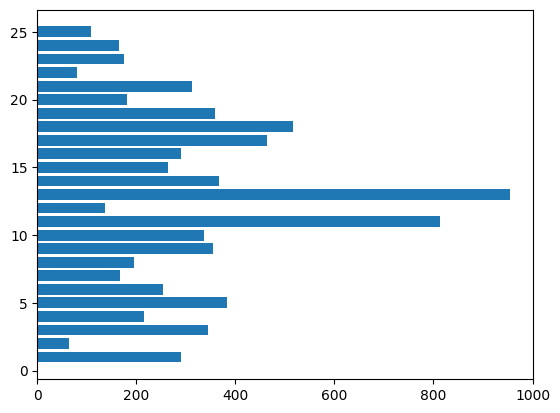

In [ ]:
plt.barh(category_counts.index, category_counts.values)
plt.show()

## Handle Missing Values

In [ ]:
df.isna().sum()

,0
fdc_id,0
protein,0
total_lipid_fat,0
carbohydrate_by_difference,0
energy,0
fiber_total_dietary,562
potassium_k,277
sodium_na,84
cholesterol,399
fatty_acids_total_trans,3614


In [ ]:
df['sugars_total'].value_counts()

,count
sugars_total,
0.00,2116
0.40,24
0.10,21
0.30,19
0.20,19
...,...
8.97,1
4.52,1
23.07,1


In [ ]:
df['sugars_total'].median()

1.34

In [ ]:
df['fiber_total_dietary'] = df['fiber_total_dietary'].fillna(df['fiber_total_dietary'].median())
df['potassium_k'] = df['potassium_k'].fillna(df['potassium_k'].median())
df['sodium_na'] = df['sodium_na'].fillna(df['sodium_na'].median())
df['cholesterol'] = df['cholesterol'].fillna(df['cholesterol'].median())
df['fatty_acids_total_trans'] = df['fatty_acids_total_trans'].fillna(0)
df['fatty_acids_total_saturated'] = df['fatty_acids_total_saturated'].fillna(df['fatty_acids_total_saturated'].median())
df['sugars_total'] = df['sugars_total'].fillna(df['sugars_total'].median())

In [ ]:
df.isna().sum()

,0
fdc_id,0
protein,0
total_lipid_fat,0
carbohydrate_by_difference,0
energy,0
fiber_total_dietary,0
potassium_k,0
sodium_na,0
cholesterol,0
fatty_acids_total_trans,0


## Check Outliers

In [ ]:
df.columns

Index(['fdc_id', 'protein', 'total_lipid_fat', 'carbohydrate_by_difference',
       'energy', 'fiber_total_dietary', 'potassium_k', 'sodium_na',
       'cholesterol', 'fatty_acids_total_trans', 'fatty_acids_total_saturated',
       'sugars_total', 'description', 'food_category_id'],
      dtype='object')

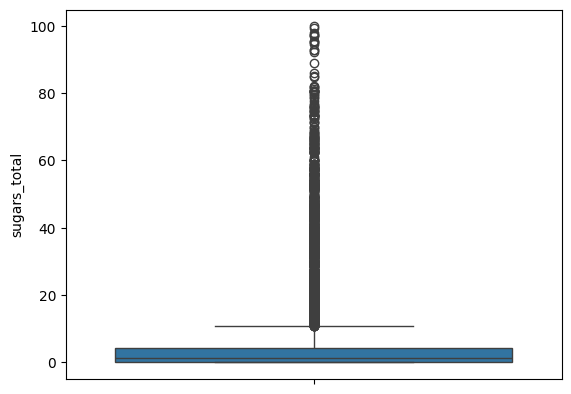

In [ ]:
sns.boxplot(y="sugars_total", data=df)
plt.show()

In [ ]:
df.loc[df.potassium_k > 10000, ["description","potassium_k"]]

,description,potassium_k
5293,"Leavening agents, baking powder, low-sodium",10100.0
7529,"Leavening agents, cream of tartar",16500.0


## Create Target Column

### Nutri-Score

Nutri-Score is calculated per 100g by subtracting positive points (fiber, protein, fruits/vegetables) from negative points (energy, sugar, salt, saturated fat)

In [ ]:
energy_bins = [-1,80,160,240,320,400,480,560,640,720,800,np.inf]
sugar_bins = [-1,4.5,9,13.5,18,22.5,27,31,36,40,45,np.inf]
satfat_bins = [-1,1,2,3,4,5,6,7,8,9,10,np.inf]
sodium_bins = [-1,90,180,270,360,450,540,630,720,810,900,np.inf]
fiber_bins = [-1,0.7,1.4,2.1,2.8,3.5,np.inf]
protein_bins = [-1,1.6,3.2,4.8,6.4,8.0,np.inf]
fvnl_categories = [9, 11, 12, 16]

In [ ]:
df["energy_points"] = pd.cut(df["energy"], bins=energy_bins, labels=range(11)).astype(int)
df["sugar_points"] = pd.cut(df["sugars_total"], bins=sugar_bins, labels=range(11)).astype(int)
df["satfat_points"] = pd.cut(df["fatty_acids_total_saturated"], bins=satfat_bins, labels=range(11)).astype(int)
df["sodium_points"] = pd.cut(df["sodium_na"], bins=sodium_bins, labels=range(11)).astype(int)
df["fiber_points"] = pd.cut(df["fiber_total_dietary"], bins=fiber_bins, labels=range(6)).astype(int)
df["protein_points"] = pd.cut(df["protein"], bins=protein_bins, labels=range(6)).astype(int)
df["fvnl_points"] = np.where(df["food_category_id"].isin(fvnl_categories),5,0)

In [ ]:
df["A_points"] = df["energy_points"] + df["sugar_points"] + df["satfat_points"] + df["sodium_points"]
df["protein_points_adj"] = np.where(df["A_points"] < 11, df["protein_points"], 0)
df["C_points"] = df["fiber_points"] + df["protein_points_adj"] + df["fvnl_points"]
df["nutri_score"] =  df["A_points"] - df["C_points"]

In [ ]:
df["nutri_grade"] = pd.cut(
    df["nutri_score"],
    bins=[-np.inf, -1, 2, 10, 18, np.inf],
    labels=["A", "B", "C", "D", "E"]
)

In [ ]:
label_counts = df["nutri_grade"].value_counts()
label_counts

,count
nutri_grade,
A,3181
B,1487
D,1305
C,1191
E,629


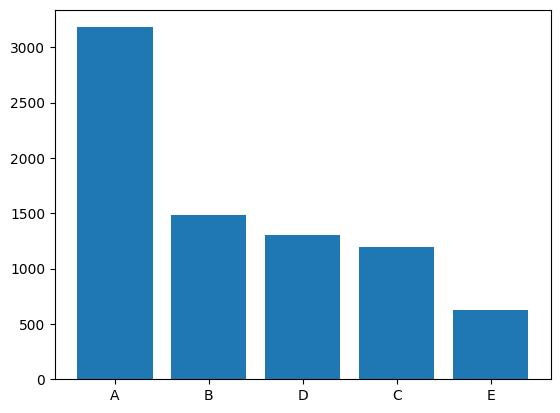

In [ ]:
plt.bar(label_counts.index, label_counts.values)
plt.show()

In [ ]:
df.head()

,fdc_id,protein,total_lipid_fat,carbohydrate_by_difference,energy,fiber_total_dietary,potassium_k,sodium_na,cholesterol,fatty_acids_total_trans,...,satfat_points,sodium_points,fiber_points,protein_points,fvnl_points,A_points,protein_points_adj,C_points,nutri_score,nutri_grade
0,167512,5.88,13.24,41.18,307.0,1.2,238.0,1059.0,0.0,4.412,...,2,10,1,3,0,16,0,1,15,D
1,167513,4.34,11.27,53.42,330.0,1.4,238.0,780.0,0.0,4.290,...,3,8,1,2,0,19,0,1,18,D
2,167514,6.10,3.70,79.80,377.0,0.3,238.0,2182.0,8.0,0.000,...,1,10,0,3,0,15,0,0,15,D
3,167515,8.00,1.80,46.00,232.0,0.3,238.0,345.0,8.0,0.082,...,0,3,0,4,0,5,4,4,1,B
4,167516,6.58,9.22,41.05,273.0,2.2,126.0,621.0,15.0,0.000,...,1,6,3,4,0,10,4,7,3,C


## Drop Unwanted Features

In [ ]:
df.columns

Index(['fdc_id', 'protein', 'total_lipid_fat', 'carbohydrate_by_difference',
       'energy', 'fiber_total_dietary', 'potassium_k', 'sodium_na',
       'cholesterol', 'fatty_acids_total_trans', 'fatty_acids_total_saturated',
       'sugars_total', 'description', 'food_category_id', 'energy_points',
       'sugar_points', 'satfat_points', 'sodium_points', 'fiber_points',
       'protein_points', 'fvnl_points', 'A_points', 'protein_points_adj',
       'C_points', 'nutri_score', 'nutri_grade'],
      dtype='object')

In [ ]:
drop_cols = [
    "fdc_id",
    "description",
    "energy_points",
    "sugar_points",
    "satfat_points",
    "sodium_points",
    "fiber_points",
    "protein_points",
    "fvnl_points",
    "A_points",
    "protein_points_adj",
    "C_points",
    "nutri_score"
]

df.drop(columns=drop_cols, axis=1, inplace=True)
df.shape

(7793, 13)

## Input Output Split

In [ ]:
x = df.drop(['nutri_grade'], axis=1)
y = df['nutri_grade']

In [ ]:
x.shape, y.shape

((7793, 12), (7793,))

## Feature Correlation

In [ ]:
numeric_cols = [
    'protein',
    'total_lipid_fat',
    'carbohydrate_by_difference',
    'energy',
    'fiber_total_dietary',
    'potassium_k',
    'sodium_na',
    'cholesterol',
    'fatty_acids_total_trans',
    'fatty_acids_total_saturated',
    'sugars_total'
]

categorical_cols = ['food_category_id']

In [ ]:
x[numeric_cols].corr()

,protein,total_lipid_fat,carbohydrate_by_difference,energy,fiber_total_dietary,potassium_k,sodium_na,cholesterol,fatty_acids_total_trans,fatty_acids_total_saturated,sugars_total
protein,1.000000,0.055735,-0.308815,0.126493,-0.079597,0.233522,0.003246,0.279239,-0.025669,0.044055,-0.268364
total_lipid_fat,0.055735,1.000000,-0.075165,0.825527,-0.015174,-0.036080,0.011505,0.084850,0.300593,0.761285,-0.022090
carbohydrate_by_difference,-0.308815,-0.075165,1.000000,0.434860,0.441473,0.153571,0.063945,-0.214379,-0.050234,-0.071910,0.587326
energy,0.126493,0.825527,0.434860,1.000000,0.187181,0.097066,0.049535,0.026186,0.222858,0.626029,0.258363
fiber_total_dietary,-0.079597,-0.015174,0.441473,0.187181,1.000000,0.342249,-0.000958,-0.141299,-0.044229,-0.072136,0.078361
potassium_k,0.233522,-0.036080,0.153571,0.097066,0.342249,1.000000,0.005136,-0.009069,-0.045265,-0.056983,0.005587
sodium_na,0.003246,0.011505,0.063945,0.049535,-0.000958,0.005136,1.000000,-0.014461,0.001193,0.000584,-0.000345
cholesterol,0.279239,0.084850,-0.214379,0.026186,-0.141299,-0.009069,-0.014461,1.000000,-0.000605,0.087445,-0.124408
fatty_acids_total_trans,-0.025669,0.300593,-0.050234,0.222858,-0.044229,-0.045265,0.001193,-0.000605,1.000000,0.185113,-0.026451
fatty_acids_total_saturated,0.044055,0.761285,-0.071910,0.626029,-0.072136,-0.056983,0.000584,0.087445,0.185113,1.000000,0.038657


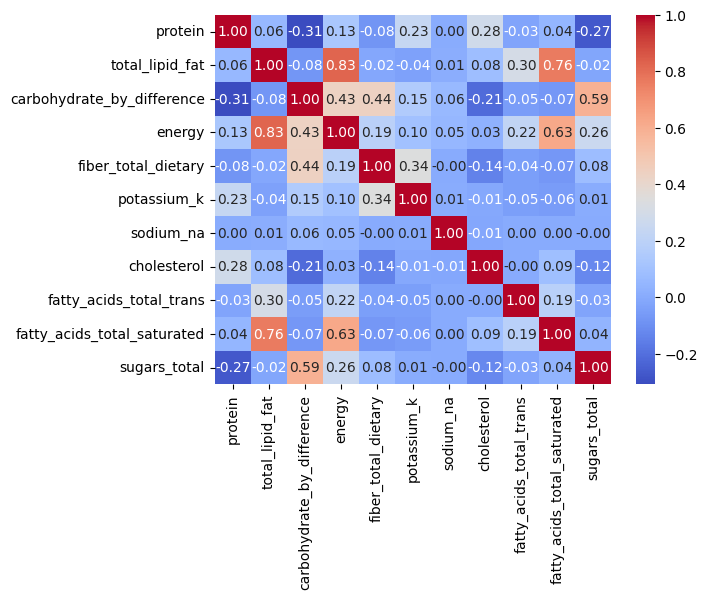

In [ ]:
sns.heatmap(x[numeric_cols].corr(), cmap='coolwarm', annot=True, fmt='.2f')
plt.show()

## Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
x_train.shape, x_test.shape

((6234, 12), (1559, 12))

# Model Creation

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

## KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

preprocessor_knn = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

pipeline_knn = Pipeline([
    ('preprocessor', preprocessor_knn),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

pipeline_knn.fit(x_train, y_train)
y_pred_knn = pipeline_knn.predict(x_test)

In [ ]:
cm = confusion_matrix(y_test, y_pred_knn)
cm

array([[622,  25,   4,   1,   0],
       [ 41, 228,  18,   2,   0],
       [ 21,  53, 138,  26,   0],
       [  2,   9,  27, 201,  15],
       [  0,   0,   1,  16, 109]])

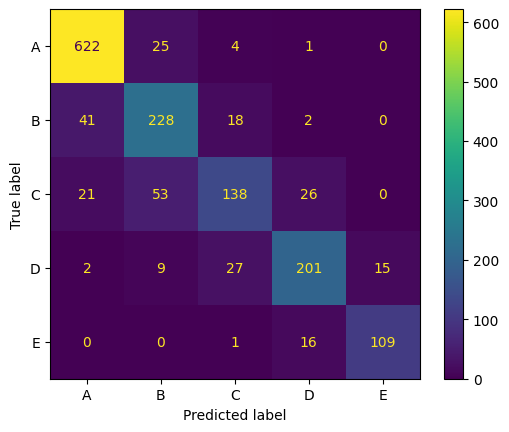

In [ ]:
cmd = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
cmd.plot()
plt.show()

In [ ]:
score_knn = accuracy_score(y_test, y_pred_knn)
score_knn

0.8325849903784477

In [ ]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           A       0.91      0.95      0.93       652
           B       0.72      0.79      0.75       289
           C       0.73      0.58      0.65       238
           D       0.82      0.79      0.80       254
           E       0.88      0.87      0.87       126

    accuracy                           0.83      1559
   macro avg       0.81      0.80      0.80      1559
weighted avg       0.83      0.83      0.83      1559



## Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

preprocessor_nb = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

pipeline_nb = Pipeline([
    ('preprocessor', preprocessor_nb),
    ('classifier', GaussianNB())
])

pipeline_nb.fit(x_train, y_train)
y_pred_nb = pipeline_nb.predict(x_test)

In [ ]:
cm = confusion_matrix(y_test, y_pred_nb)
cm

array([[496,  86,  25,  21,  24],
       [ 34, 199,   8,  11,  37],
       [ 18,  81,  41,  55,  43],
       [  2,  13,  25, 111, 103],
       [  0,   0,   5,  14, 107]])

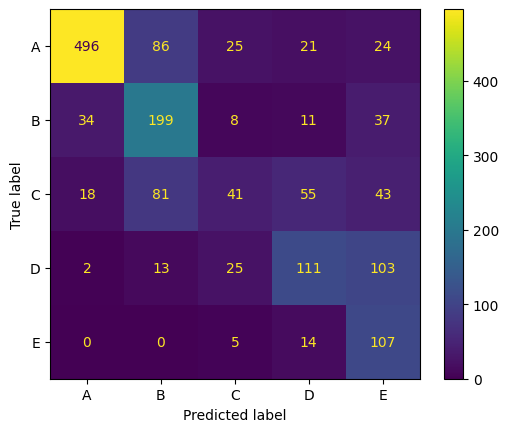

In [ ]:
cmd = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
cmd.plot()
plt.show()

In [ ]:
score_nb = accuracy_score(y_test, y_pred_nb)
score_nb

0.6119307248236049

In [ ]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           A       0.90      0.76      0.83       652
           B       0.53      0.69      0.60       289
           C       0.39      0.17      0.24       238
           D       0.52      0.44      0.48       254
           E       0.34      0.85      0.49       126

    accuracy                           0.61      1559
   macro avg       0.54      0.58      0.52      1559
weighted avg       0.65      0.61      0.61      1559



## Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

preprocessor_dt = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

pipeline_dt = Pipeline([
    ('preprocessor', preprocessor_dt),
    ('classifier', DecisionTreeClassifier(criterion='entropy', random_state=42))
])

pipeline_dt.fit(x_train, y_train)
y_pred_dt = pipeline_dt.predict(x_test)

In [ ]:
cm = confusion_matrix(y_test, y_pred_dt)
cm

array([[617,  29,   5,   1,   0],
       [ 25, 244,  20,   0,   0],
       [  7,  30, 177,  23,   1],
       [  0,   1,  27, 216,  10],
       [  0,   0,   0,  16, 110]])

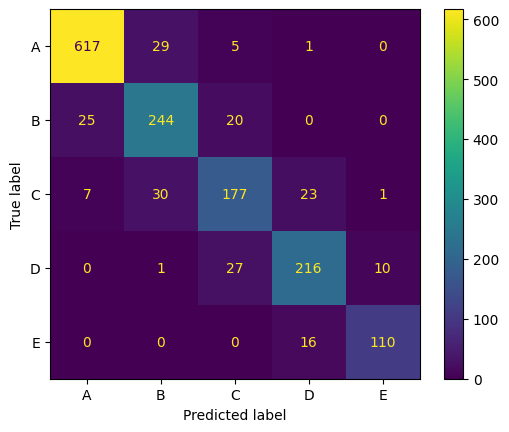

In [ ]:
cmd = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
cmd.plot()
plt.show()

In [ ]:
score_dt = accuracy_score(y_test, y_pred_dt)
score_dt

0.8749198203976908

In [ ]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           A       0.95      0.95      0.95       652
           B       0.80      0.84      0.82       289
           C       0.77      0.74      0.76       238
           D       0.84      0.85      0.85       254
           E       0.91      0.87      0.89       126

    accuracy                           0.87      1559
   macro avg       0.86      0.85      0.85      1559
weighted avg       0.88      0.87      0.87      1559



## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

preprocessor_rf = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

pipeline_rf = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('classifier', RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=42))
])

pipeline_rf.fit(x_train, y_train)
y_pred_rf = pipeline_rf.predict(x_test)

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)
cm

array([[639,   9,   4,   0,   0],
       [ 25, 241,  23,   0,   0],
       [  2,  28, 183,  25,   0],
       [  0,   0,  21, 223,  10],
       [  0,   0,   0,  18, 108]])

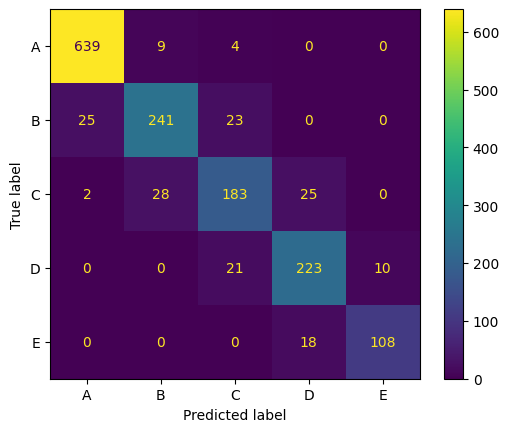

In [ ]:
cmd = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
cmd.plot()
plt.show()

In [ ]:
score_rf = accuracy_score(y_test, y_pred_rf)
score_rf

0.8941629249518922

In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           A       0.96      0.98      0.97       652
           B       0.87      0.83      0.85       289
           C       0.79      0.77      0.78       238
           D       0.84      0.88      0.86       254
           E       0.92      0.86      0.89       126

    accuracy                           0.89      1559
   macro avg       0.87      0.86      0.87      1559
weighted avg       0.89      0.89      0.89      1559



# Model Comparison

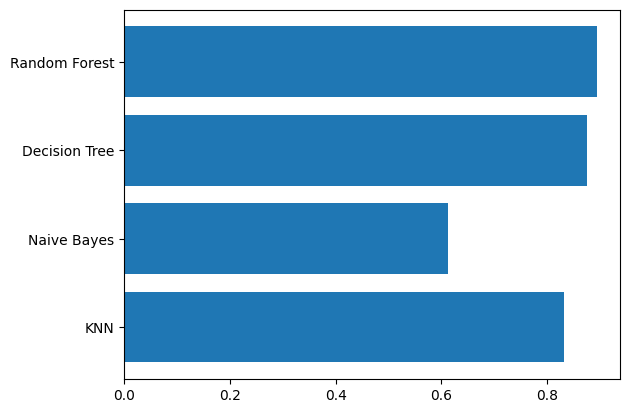

In [ ]:
model_names = ['KNN', 'Naive Bayes', 'Decision Tree', 'Random Forest']
model_accuracy = [score_knn, score_nb, score_dt, score_rf]
plt.barh(model_names, model_accuracy)
plt.show()

# Hyperparameter Tuning

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__criterion': ['entropy', 'gini', 'log_loss']
}

grid_search = GridSearchCV(
    pipeline_rf,
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         'passthrough',
                                                                         ['protein',
                                                                          'total_lipid_fat',
                                                                          'carbohydrate_by_difference',
                                                                          'energy',
                                                                          'fiber_total_dietary',
                                                                          'potassium_k',
                                                                          'sodium_na',
                                                                          'cholesterol',
                                                                          'fatty_acids_total_trans',
                                                                          'fatty_acids_total_saturated',
                                                                          'sugars_total']),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['food_category_id'])])),
                                       ('classifier',
                                        RandomForestClassifier(criterion='entropy',
                                                               random_state=42))]),
             param_grid={'classifier__criterion': ['entropy', 'gini',
                                                   'log_loss'],
                         'classifier__n_estimators': [100, 200, 300]},
             scoring='accuracy')

In [ ]:
grid_search.best_params_

{'classifier__criterion': 'entropy', 'classifier__n_estimators': 200}

In [ ]:
best_rf = grid_search.best_estimator_
best_rf.score(x_test, y_test)

0.8960872354073124

In [ ]:
pipeline_rf.fit(x_train, y_train)
y_pred = pipeline_rf.predict(x_test)

# Performance Evaluation

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
cm = confusion_matrix(y_test, y_pred_rf)
cm

array([[639,   9,   4,   0,   0],
       [ 25, 241,  23,   0,   0],
       [  2,  28, 183,  25,   0],
       [  0,   0,  21, 223,  10],
       [  0,   0,   0,  18, 108]])

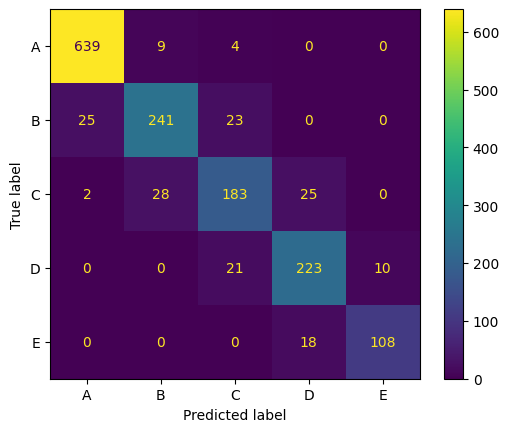

In [ ]:
cmd = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
cmd.plot()
plt.show()

In [ ]:
score = accuracy_score(y_test, y_pred_rf)
score

0.8941629249518922

In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           A       0.96      0.98      0.97       652
           B       0.87      0.83      0.85       289
           C       0.79      0.77      0.78       238
           D       0.84      0.88      0.86       254
           E       0.92      0.86      0.89       126

    accuracy                           0.89      1559
   macro avg       0.87      0.86      0.87      1559
weighted avg       0.89      0.89      0.89      1559



# Custom Evaluation

In [ ]:
custom_food = {
    'protein': 6.3,
    'total_lipid_fat': 4.8,
    'carbohydrate_by_difference': 0.36,
    'energy': 72,
    'fiber_total_dietary': 0,
    'potassium_k': 69,
    'sodium_na': 71,
    'cholesterol': 186,
    'fatty_acids_total_trans': 0.02,
    'fatty_acids_total_saturated': 1.6,
    'sugars_total': 0,
    'food_category_id': 1
}

custom_df = pd.DataFrame([custom_food])

In [ ]:
prediction = pipeline_rf.predict(custom_df)

print("Predicted class:", prediction[0])

Predicted class: A


# Saving Model

In [ ]:
import joblib

# Save model
joblib.dump(pipeline_rf, "pipeline_rf.pkl")

['pipeline_rf.pkl']